# Clustering de clientes con K-means

#### ¿El algoritmo encuentra agrupaciones naturales de clientes que se parecen entre sí en edad/ingreso/gasto?

In [1]:
# Librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
RUTA_DATOS = '../DATA/Mall_Customers.csv'
SEED = 123 #semilla ya que K-means es estocástico

In [3]:
mall =pd.read_csv(RUTA_DATOS)

In [4]:
mall

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
# Preparación de datos

variables = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
mall_datos = mall[variables]

mall_datos.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [6]:
escalador = StandardScaler()

mall_escalado = escalador.fit_transform(mall_datos)

In [7]:
mall_escalado

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

In [8]:
## ¿Cuántos clusters (k)? Utilizamos el método del codo:

wss = []
valores_k = range(1,11)

for k in valores_k:
    modelo = KMeans(n_clusters=k, n_init=25, random_state=SEED)
    modelo.fit(mall_escalado)
    wss.append(modelo.inertia_) # intertia_ es lo mismo que WSS

In [9]:
wss

[600.0,
 389.38618895643714,
 295.2602964886118,
 205.2251474767592,
 168.24758017556837,
 133.86833362685584,
 117.13060763524547,
 104.02116700198584,
 92.19966535932784,
 81.97085122186259]

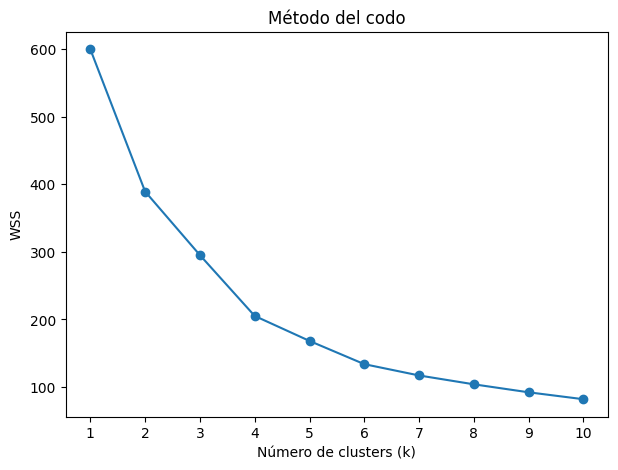

In [10]:
plt.figure(figsize=(7, 5))
plt.plot(valores_k, wss, marker="o")
plt.title("Método del codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("WSS")
plt.xticks(list(valores_k))
plt.show()

In [40]:
# K obtenido a partir del método del codo
K = 4        # En K = 6 también se aprecia un codo pero tener 6 clasificaciones se vuelve más complejo

# Se ejecuta el algoritmo
kmeans = KMeans(n_clusters=K, n_init=25, random_state=SEED)

In [41]:
kmeans.fit_predict(mall_escalado)

array([2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2,
       1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2,
       2, 1, 1, 2, 1, 1, 2, 2, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1, 1, 1,
       1, 2, 3, 2, 2, 2, 1, 1, 1, 1, 2, 3, 0, 0, 3, 0, 3, 0, 1, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 1, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0], dtype=int32)

In [42]:
mall["cluster"] = kmeans.fit_predict(mall_escalado).astype(str)

In [43]:
mall

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,0
196,197,Female,45,126,28,3
197,198,Male,32,126,74,0
198,199,Male,32,137,18,3


In [44]:
# Se ve cuántos clientes pertenecen a cada clúster
mall["cluster"].value_counts().sort_index() # Podría ser también un gráfico de barra

cluster
0    40
1    65
2    57
3    38
Name: count, dtype: int64

In [45]:
# La idea luego es denominar a los clúster (que no se llamen numéricamente)

## Visualización de Clusters

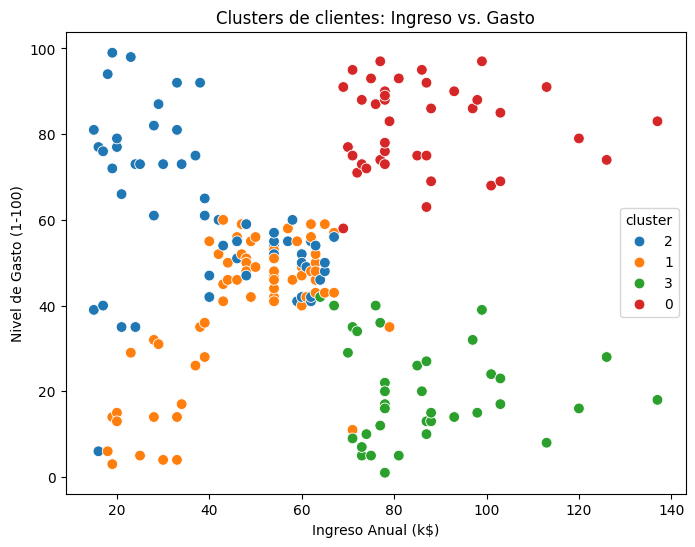

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=mall, x="Annual Income (k$)", y="Spending Score (1-100)", 
                hue="cluster", palette="tab10", s=60, ax=ax)
ax.set_xlabel("Ingreso Anual (k$)")
ax.set_ylabel("Nivel de Gasto (1-100)")
ax.set_title("Clusters de clientes: Ingreso vs. Gasto")
plt.show()

In [47]:
# Clúster 0 es de gente de altos ingresos y altos gastos
# Clúster 1 es de gente pobre
# Clúster 2 es de gente irresponsable financieramente
# Clúster 3 es de gente amarrete

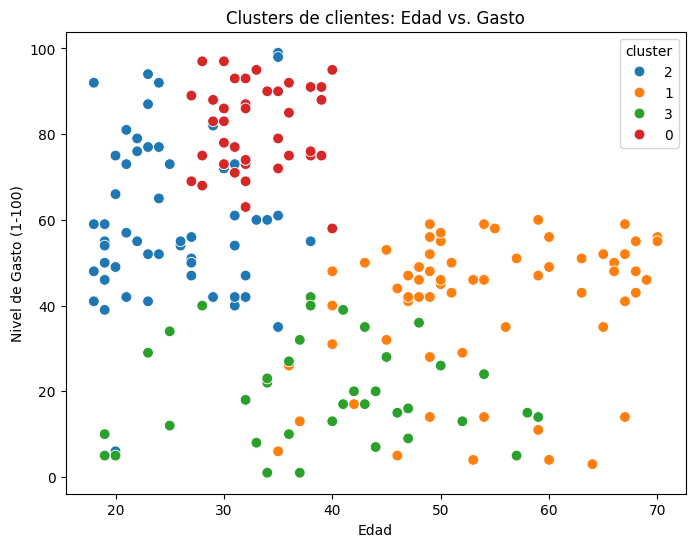

In [48]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=mall, x="Age", y="Spending Score (1-100)", 
                hue="cluster", palette="tab10", s=60, ax=ax)
ax.set_xlabel("Edad")
ax.set_ylabel("Nivel de Gasto (1-100)")
ax.set_title("Clusters de clientes: Edad vs. Gasto")
plt.show()

In [ ]:
# Clúster 0 es de adultos jovenes de altos ingresos y altos gastos. TINKS
# Clúster 1 es de adultos y adultos mayores pobres y de gastos medios
# Clúster 2 es de jovenes irresponsables financieramente. Impulsivos y quizás endeudados
# Clúster 3 es de gente amarrete etariamente transversal